# Importação das bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import duckdb as db
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

# **Carregamento dos dados de treino e compreensão de dados**

In [2]:
with open("data/train.csv", "r", encoding = "utf-8") as arquivo:
    data = pd.read_csv(arquivo)

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data.shape

(891, 12)

In [7]:
data.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [8]:
data.dtypes.sort_values(ascending = True)

PassengerId      int64
Survived         int64
Pclass           int64
SibSp            int64
Parch            int64
Age            float64
Fare           float64
Name            object
Sex             object
Ticket          object
Cabin           object
Embarked        object
dtype: object

### **Removendo a coluna "Cabin", pois tem uma grande quantidade de dados nulos**

In [9]:
apagarColuna = data.columns[(data.isnull().sum()/data.shape[0]) > 0.2]

data = data.drop(apagarColuna, axis = 1)

data_limpo = data

## **Consultas SQL para conseguir insights, junto com a visualização gráfica**

### **Quantidade de sobreviventes**

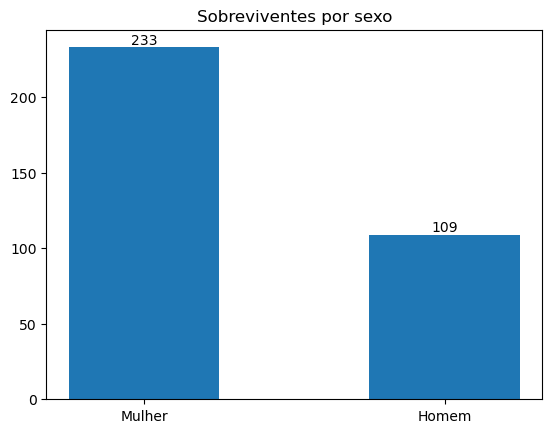

In [10]:
sobreviveu_overall = db.query(
"""
SELECT
  CASE
    WHEN Sex = 'female' THEN 'Mulher'
    WHEN Sex = 'male' THEN 'Homem'
  END AS Sexo,
  Survived AS Sobreviveu,
  COUNT(*) AS Quantidade
FROM data_limpo
WHERE Sex IN ('female','male') AND Survived = 1
GROUP BY Sex, Survived
ORDER BY Quantidade DESC;
"""
).to_df()

fig, ax = plt.subplots()
barras = ax.bar(data = sobreviveu_overall, x = sobreviveu_overall.Sexo, height = 'Quantidade', width = 0.5, align = 'center')
ax.bar_label(barras, padding = 0)
plt.title('Sobreviventes por sexo')
plt.show()

### **Quantidade de sobreviventes por portos de embarque**

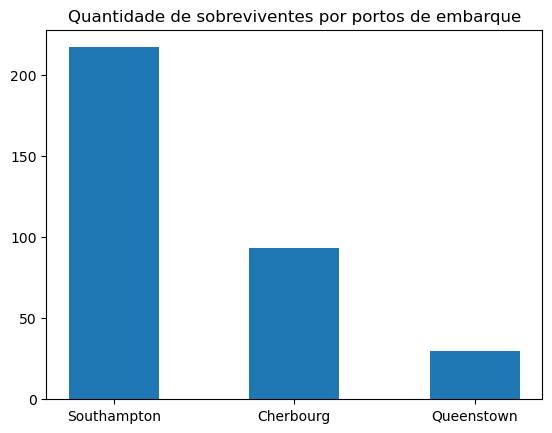

In [11]:
porto_embarque = db.query(
"""
SELECT
    CASE
        WHEN Embarked = 'C' THEN 'Cherbourg'
        WHEN Embarked = 'Q' THEN 'Queenstown'
        WHEN Embarked = 'S' THEN 'Southampton'
        END AS Porto, COUNT(*) AS Quantidade
FROM data_limpo
WHERE Survived = 1 AND Embarked IN ('C', 'Q', 'S') AND Embarked IS NOT NULL
GROUP BY Embarked, Survived
ORDER BY Quantidade DESC;
""").to_df()

fig, ax = plt.subplots()
barras = ax.bar(data = porto_embarque, x = porto_embarque.Porto, height = porto_embarque.Quantidade, width = 0.5)
plt.title('Quantidade de sobreviventes por portos de embarque')
plt.show()

### **Sobreviventes por diferentes faixas etárias**

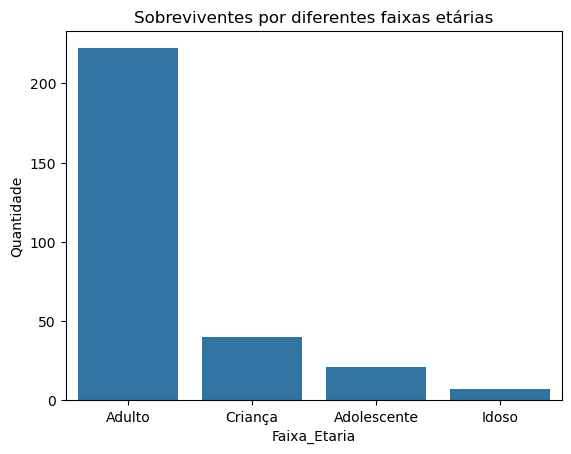

In [12]:
idade_sobrevivente = db.query(
"""
SELECT
    CASE
        WHEN Age <= 12 THEN 'Criança'
        WHEN Age <= 17 THEN 'Adolescente'
        WHEN Age <= 59 THEN 'Adulto'
        WHEN Age >= 60 THEN 'Idoso'
    END AS Faixa_Etaria, COUNT(*) AS Quantidade
FROM data_limpo
WHERE Survived = 1 AND Age IS NOT NULL
GROUP BY faixa_etaria
ORDER BY Quantidade DESC;
"""
).to_df()

sb.barplot(data=idade_sobrevivente, x='Faixa_Etaria', y='Quantidade', width = 0.8)
plt.title('Sobreviventes por diferentes faixas etárias')
plt.show()

### **Porcentagem de sobreviventes por porto de embarque**

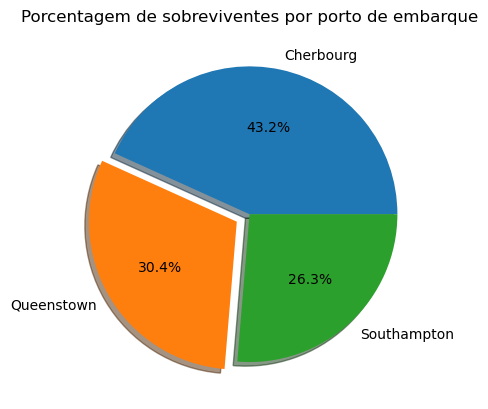

In [13]:
embarque_porcentagem = db.query(
"""
SELECT
  CASE
    WHEN Embarked = 'C' THEN 'Cherbourg'
    WHEN Embarked = 'S' THEN 'Southampton'
    WHEN Embarked = 'Q' THEN 'Queenstown'
  END AS Porto,
  COUNT(*) AS Total,
  SUM(Survived) AS Sobrevivente,
  ROUND(100 * SUM(Survived) / COUNT(*), 2) AS Porcentagem
FROM data_limpo
WHERE Embarked IS NOT NULL
GROUP BY Embarked;
"""
).to_df()

fig, ax = plt.subplots()
ax.pie(embarque_porcentagem.Porcentagem, labels = embarque_porcentagem.Porto, autopct='%1.1f%%', explode = (0, 0.1, 0), shadow = True)
plt.title('Porcentagem de sobreviventes por porto de embarque')
plt.show()

### **Porcentagem de sobreviventes por diferentes classes**

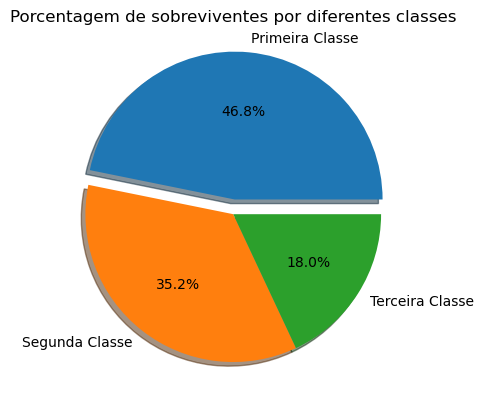

In [14]:
porcentagem_classe = db.query(
"""
SELECT
  CASE
    WHEN Pclass = 1 THEN 'Primeira Classe'
    WHEN Pclass = 2 THEN 'Segunda Classe'
    WHEN Pclass = 3 THEN 'Terceira Classe'
  END AS Classe,
  COUNT(*) AS Total,
  SUM(Survived) AS Sobrevivente,
  ROUND(100 * SUM(Survived) / COUNT(*), 2) AS Porcentagem
  FROM data_limpo
  GROUP BY Pclass
  ORDER BY Pclass;
"""
).to_df()

fig, ax = plt.subplots()
ax.pie(porcentagem_classe.Porcentagem, labels = porcentagem_classe.Classe, autopct='%1.1f%%', explode = (0.1, 0, 0), shadow = True)
plt.title('Porcentagem de sobreviventes por diferentes classes')
plt.show()

### **Porcentagem de sobreviventes por sexo**

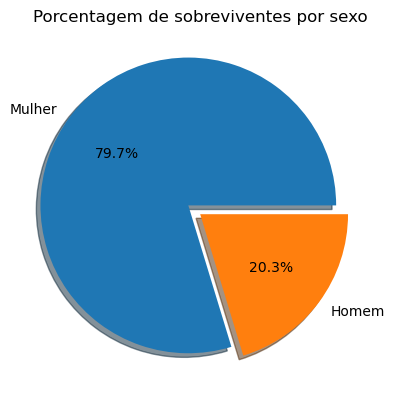

In [15]:
porcentagem_sexo = db.query(
"""
SELECT
    CASE
        WHEN Sex = 'female' THEN 'Mulher'
        WHEN Sex = 'male' THEN 'Homem'
    END AS Sexo,
    COUNT(*) AS Total,
    SUM(Survived) AS Sobreviveu,
    ROUND(100 * SUM(Survived) / COUNT(*), 2) AS Porcentagem
    FROM data_limpo
    GROUP BY Sex
    ORDER BY Total;
"""
).to_df()

fig, ax = plt.subplots()
ax.pie(porcentagem_sexo.Porcentagem, labels = porcentagem_sexo.Sexo, autopct = '%1.1f%%', explode = (0.1, 0), shadow = True)
plt.title('Porcentagem de sobreviventes por sexo')
plt.show()

### **Relação de sobrevivência entre sexo e o tipo de classe**

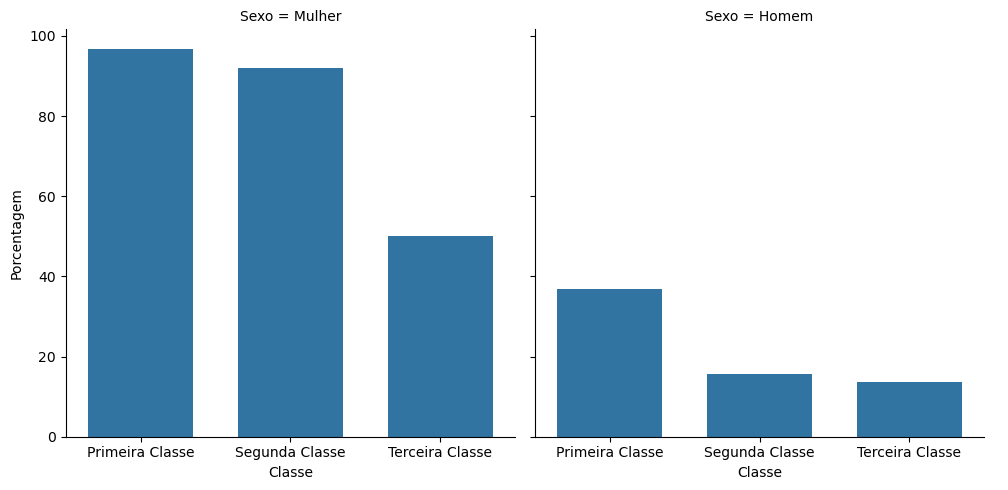

In [16]:
sexoEclasse_sobrevivente = db.query(
"""
SELECT
  CASE
    WHEN Sex = 'female' THEN 'Mulher'
    WHEN Sex = 'male' THEN 'Homem'
  END AS Sexo,
  CASE
    WHEN Pclass = 1 THEN 'Primeira Classe'
    WHEN Pclass = 2 THEN 'Segunda Classe'
    WHEN Pclass = 3 THEN 'Terceira Classe'
  END AS Classe,
  SUM(Survived) AS Sobreviveu,
  ROUND(100 * SUM(Survived) / COUNT(*), 2) AS Porcentagem
  FROM data_limpo
  GROUP BY Sex, Pclass
  ORDER BY Sex, Pclass;
""").to_df()

sb.catplot(data = sexoEclasse_sobrevivente, x = 'Classe', y = 'Porcentagem', col = 'Sexo', kind = 'bar', width = 0.7)
plt.show()

### **Criando novas features**

In [17]:
data_limpo['familia_tamanho'] = data_limpo.SibSp + data_limpo.Parch + 1

data_limpo['esta_sozinho'] = [
    1 if x == 1 else 0
    for x in data_limpo.familia_tamanho
]

# **Tratamento e modelagem dos dados**

In [18]:
X = data_limpo.drop(['Survived', 'Embarked', 'PassengerId'], axis = 1)
y = data_limpo['Survived']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 42)

### **Separação das variáveis para aplicar diferentes tipos de tratamento para os dados**

In [19]:
variavel_numerica = [x for x in list(data_limpo.select_dtypes(include=['int64', 'float64']).columns) if x not in ['Survived','PassengerId']]

variavel_categorica = [x for x in list(data_limpo.select_dtypes(include = ['object']).columns) if x not in ['Name', 'Embarked']]

### **Pipeline de pré-processamento**

### **Utilizando três diferentes modelos e analisando a performance de cada**

In [20]:
pipeline_numerica = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

pipeline_categorica = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', pipeline_numerica, variavel_numerica),
    ('categorical', pipeline_categorica, variavel_categorica)
])

In [21]:
logreg = LogisticRegression(solver = 'liblinear', random_state = 42, max_iter = 1000)

randomforest = RandomForestClassifier(random_state = 42)

decisiontree = DecisionTreeClassifier(random_state = 42)

In [22]:
pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', logreg)
])

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', decisiontree)
])

pipeline_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', randomforest)
])

In [23]:
parametros_logreg = {
    'modelo__C' : [0.01, 0.1, 1, 10, 100],
    'modelo__penalty' : ['l1','l2'],
}

parametros_tree = {
    'modelo__max_depth' : [None, 3, 5, 7, 10],
    'modelo__min_samples_split' : [2, 5, 10],
    'modelo__min_samples_leaf' : [1, 2, 4],
    'modelo__criterion' : ['gini', 'entropy']
}

parametros_forest = {
    'modelo__n_estimators' : [100,200,300],
    'modelo__max_depth' : [None, 5, 10, 15],
    'modelo__min_samples_split' : [2, 5, 10],
    'modelo__min_samples_leaf' : [1, 2, 4]
}

In [24]:
grid_logreg = GridSearchCV(
    pipeline_logreg,
    parametros_logreg,
    cv = 10,
    n_jobs = -1,
    verbose = 1,
    error_score = 'raise'
)

grid_tree = GridSearchCV(
    pipeline_tree,
    parametros_tree,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

grid_forest = GridSearchCV(
    pipeline_forest,
    parametros_forest,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

### **Procurando os melhores parâmetros de cada modelo**

In [25]:
grid_logreg.fit(X_treino, y_treino)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=10, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'familia_tamanho',
                                                                          'esta_sozinho']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Ticket'])])),
                                       ('modelo',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10, 100],
                         'modelo__penalty': ['l1', 'l2']},
             verbose=1)

In [26]:
grid_tree.fit(X_treino, y_treino)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'familia_tamanho',
                                                                          'esta_sozinho']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Ticket'])])),
                                       ('modelo',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [None, 3, 5, 7, 10],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [27]:
grid_forest.fit(X_treino, y_treino)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'familia_tamanho',
                                                                          'esta_sozinho']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Ticket'])])),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [None, 5, 10, 15],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10],
                         'modelo__n_estimators': [100, 200, 300]},
             scoring='accuracy')

### **Olhando o resultado dos melhores parâmetros de cada modelo**

In [28]:
print('Resultado Regressão Logística:\n')
print('Melhores hiperparâmetros encontrados:')
print(f'{grid_logreg.best_params_}\n')
print('Melhores resultados: ')
print(f'{grid_logreg.best_score_:.2f}\n\n\n')

print('Resultado Árvore de Decisão:\n')
print('Melhores hiperparâmetros encontrados:')
print(f'{grid_tree.best_params_}\n')
print('Melhores resultados: ')
print(f'{grid_tree.best_score_:.2f}\n\n\n')

print('Resultado Classificador de Floresta Aleatória:\n')
print('Melhores hiperparâmetros encontrados:')
print(f'{grid_forest.best_params_}\n')
print('Melhores resultados: ')
print(f'{grid_forest.best_score_:.2f}')

Resultado Regressão Logística:

Melhores hiperparâmetros encontrados:
{'modelo__C': 100, 'modelo__penalty': 'l1'}

Melhores resultados: 
0.82



Resultado Árvore de Decisão:

Melhores hiperparâmetros encontrados:
{'modelo__criterion': 'gini', 'modelo__max_depth': 3, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2}

Melhores resultados: 
0.83



Resultado Classificador de Floresta Aleatória:

Melhores hiperparâmetros encontrados:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 300}

Melhores resultados: 
0.84


### **Utilizando o GridSearchCV com o VotingClassifier, procurando os melhores parâmetros,**
### **para posteriormente realizar votações baseadas na previsão dos três resultados.**

In [29]:
votacao = VotingClassifier(
    estimators = [
        ('logreg', grid_logreg.best_estimator_),
        ('tree', grid_tree.best_estimator_),
        ('forest', grid_forest.best_estimator_)
    ]
)

In [30]:
parametros_votacao = {
    'voting' : ['hard', 'soft'],
    'weights' : [
        None,
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [2, 2, 1],
        [2, 1, 2],
        [1, 2, 2],
        [2, 2, 2]
    ]
}

In [31]:
grid_votacao = GridSearchCV(
    votacao,
    parametros_votacao,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,
    error_score = 'raise'
)

In [32]:
grid_votacao.fit(X_treino, y_treino)

GridSearchCV(cv=5, error_score='raise',
             estimator=VotingClassifier(estimators=[('logreg',
                                                     Pipeline(steps=[('preprocessor',
                                                                      ColumnTransformer(transformers=[('numeric',
                                                                                                       Pipeline(steps=[('imputer',
                                                                                                                        SimpleImputer(strategy='median')),
                                                                                                                       ('scaler',
                                                                                                                        StandardScaler())]),
                                                                                                       ['Pclass',
                                                                                                        'Age',
                                                                                                        'SibSp',
                                                                                                        'Parch',
                                                                                                        'Fare',
                                                                                                        'familia_tamanho',
                                                                                                        'esta_sozinho']),
                                                                                                      ('categorical',
                                                                                                       Pipeline...
                                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                                       ('encoder',
                                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                                       ['Sex',
                                                                                                        'Ticket'])])),
                                                                     ('modelo',
                                                                      RandomForestClassifier(min_samples_split=5,
                                                                                             n_estimators=300,
                                                                                             random_state=42))]))]),
             n_jobs=-1,
             param_grid={'voting': ['hard', 'soft'],
                         'weights': [None, [1, 1, 1], [2, 1, 1], [1, 2, 1],
                                     [1, 1, 2], [2, 2, 1], [2, 1, 2], [1, 2, 2],
                                     [2, 2, 2]]},
             scoring='accuracy')

In [33]:
melhor_votacao = grid_votacao.best_estimator_

### **Analisando o resultado de cada modelo e criando uma matriz de confusão para identificar o defeito de cada modelo**


Resultado de cada modelo:


Regressão Logística:
Acurácia: 0.83
Precisão: 0.84
Recall: 0.73
F1: 0.78




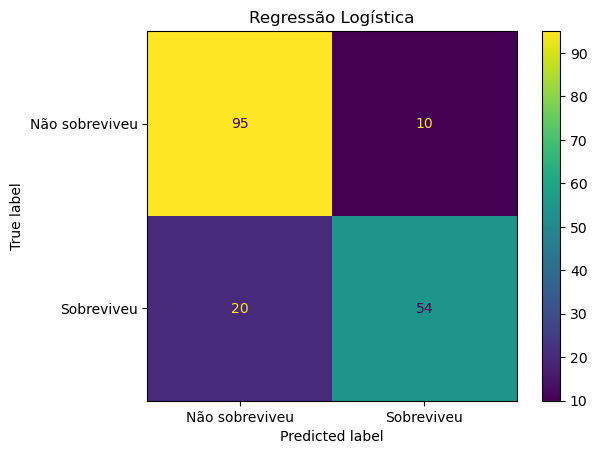



Árvore de Decisão:
Acurácia: 0.80
Precisão: 0.80
Recall: 0.69
F1: 0.74




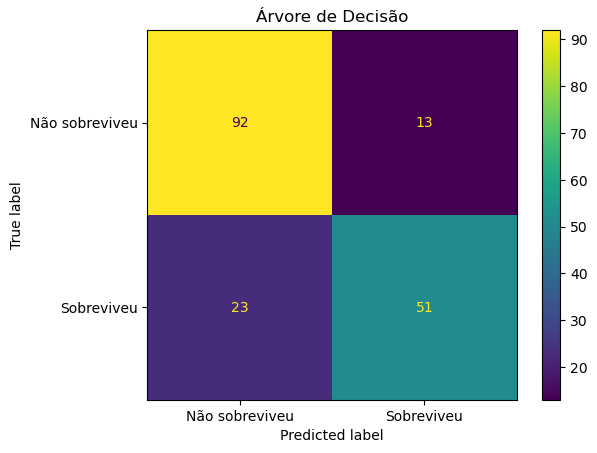



Classificação de Floresta Aleatória:
Acurácia: 0.81
Precisão: 0.82
Recall: 0.69
F1: 0.75




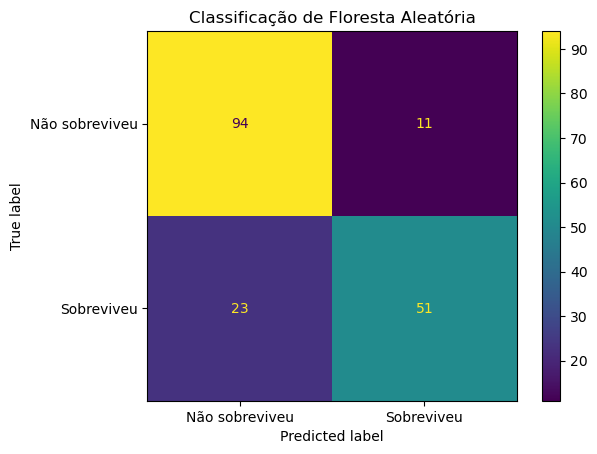



Classificador de Votação:
Acurácia: 0.82
Precisão: 0.83
Recall: 0.72
F1: 0.77




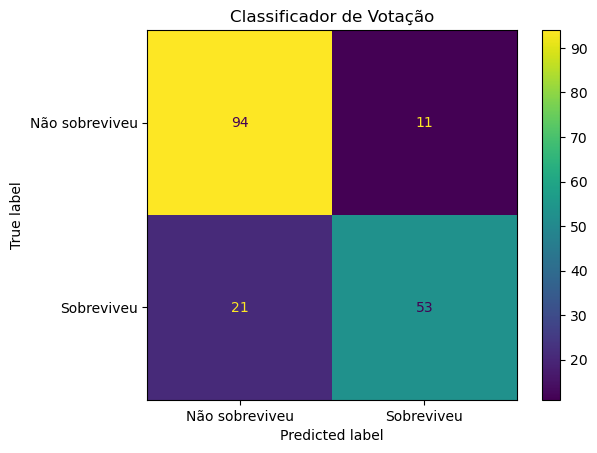

In [34]:
modelos = {
    'Regressão Logística' : grid_logreg.best_estimator_,
    'Árvore de Decisão' : grid_tree.best_estimator_,
    'Classificação de Floresta Aleatória' : grid_forest.best_estimator_,
    'Classificador de Votação' : grid_votacao.best_estimator_
}

print('\nResultado de cada modelo:')

for nome, modelo in modelos.items():
    previsao = modelo.predict(X_teste)
    
    print(f'\n\n{nome}:')
    print(f'Acurácia: {accuracy_score(y_teste, previsao):.2f}')
    print(f'Precisão: {precision_score(y_teste, previsao):.2f}')
    print(f'Recall: {recall_score(y_teste, previsao):.2f}')
    print(f'F1: {f1_score(y_teste, previsao):.2f}\n\n')

    ConfusionMatrixDisplay.from_predictions(
        y_teste,
        previsao,
        display_labels = ['Não sobreviveu', 'Sobreviveu']
    )
    plt.title(nome)
    plt.show()

### **Analisando quais features tiveram mais importância dentro do modelo**

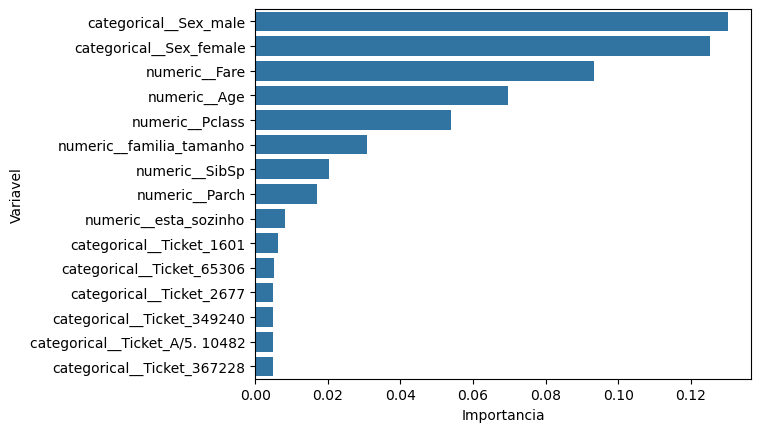

In [35]:
modelo_floresta = grid_forest.best_estimator_

modelo = modelo_floresta.named_steps['modelo']
preprocessor = modelo_floresta.named_steps['preprocessor']

features_nomes = preprocessor.get_feature_names_out()
importancias = modelo.feature_importances_

importancia = pd.DataFrame({'Variavel' : features_nomes, 'Importancia' : importancias}).sort_values('Importancia',ascending = False)

sb.barplot(data = importancia.head(15), x = 'Importancia', y = 'Variavel')
plt.show()

# **Carregamento dos dados de teste**

In [36]:
with open("data/test-selected-columns.csv", "r", encoding = "utf-8") as arquivo:
    data = pd.read_csv(arquivo)

In [37]:
data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN


In [38]:
data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [39]:
data.shape

(418, 10)

In [40]:
data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
dtype: int64

### **Apagando a coluna "Cabin", pois apresenta muitos dados nulos**

In [41]:
apagarColuna = data.columns[(data.isnull().sum()/data.shape[0]) > 0.3]

data = data.drop(apagarColuna, axis = 1)

data_Id = data['PassengerId']

data_limpo = data.drop('PassengerId', axis = 1)

### **Criação de novas features**

In [42]:
data_limpo['familia_tamanho'] = data_limpo.SibSp + data_limpo.Parch + 1

data_limpo['esta_sozinho'] = [
    1 if x == 1 else 0
    for x in data_limpo.familia_tamanho
]

### **Fazendo a previsão dos dados com os melhores parâmetros do VotingClassifier**

In [43]:
test_pred = melhor_votacao.predict(data_limpo.drop(['Name'], axis = 1))

### **Preparação para salvar o resultado em um arquivo CSV, para enviar na plataforma Kaggle**

In [44]:
data_limpo['Survived'] = test_pred
data_limpo['PassengerId'] = data_Id

In [45]:
resultado = data_limpo[['PassengerId','Survived']]

In [46]:
resultado.to_csv('resultado.csv', index = False)